# pyC2Ray GPU benchmarks: Arrhenius (NVIDIA GH200, native CUDA)

Reads the benchmark results in `benchmark_results/arrhenius/<test>/*.json` and makes the plots and tables for issues [#43](https://github.com/cosmic-reionization/pyC2Ray/issues/43) (summary), [#44](https://github.com/cosmic-reionization/pyC2Ray/issues/44) (Dardel-GPU, AMD) and [#45](https://github.com/cosmic-reionization/pyC2Ray/issues/45) (Arrhenius, NVIDIA). This notebook runs nothing on the GPU: each test is produced by a script in `benchmark_scripts/` (Slurm job scripts in `benchmark_scripts/jobs/`). Tests without results print what to run.

One notebook per system, `pyc2ray_benchmarks_<system>.ipynb` with `SYSTEM` set in the first code cell. When the HIP build on Arrhenius (HIP's CUDA backend) is benchmarked later, its results go to the same folder and appear as separate curves (the build is part of the label). Comparisons between systems go to #43. Each result file records the system, GPU, backend (HIP/CUDA) and the pyC2Ray commit it was built from.

Tests: **A** correctness gate, **B** single-GPU microbenchmarks, **C** multi-GPU / multi-node scaling, **D** end-to-end timestep, **E** roofline characterization.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

SYSTEM = 'arrhenius'  # results in benchmark_results/<SYSTEM>/
RESULTS = Path('benchmark_results')
SCRIPTS = Path('benchmark_scripts')

plt.rcParams.update({
    'font.size': 16, 'axes.labelsize': 18, 'axes.titlesize': 18,
    'xtick.labelsize': 15, 'ytick.labelsize': 15, 'legend.fontsize': 14,
    'lines.linewidth': 2, 'lines.markersize': 8,
})


def load(test):
    """All result files of a test on SYSTEM (newest last)."""
    runs = [json.loads(f.read_text()) for f in sorted((RESULTS / SYSTEM).glob(f'{test}/{test}_*.json'))]
    if not runs:
        script = SCRIPTS / f'{test}.py'
        if script.exists():
            # job script of this test, or of its group (e.g. dardel_C.sh runs C1 and C2)
            jobs = [p.name for p in (SCRIPTS / 'jobs').glob(f'{SYSTEM}_{test.split("_")[0]}.sh')] or \
                   [p.name for p in (SCRIPTS / 'jobs').glob(f'{SYSTEM}_{test[0]}.sh')]
            print(f'{test}: no results yet. Run {script}' + (f' (e.g. sbatch {SCRIPTS}/jobs/{jobs[0]})' if jobs else ''))
        else:
            print(f'{test}: not implemented yet ({script} does not exist).')
    return runs


def label(run):
    """Short plot label; commit, node, job etc. are in run['meta']."""
    m = run['meta']
    return f"{m['system']}, {m['gpu']}, {m.get('build', m['backend'])}"


def case_label(N=None, nsrc=None, R=None, per_gpu=False):
    """Legend text of a case, e.g. '$N_\\mathrm{mesh}$=256, $N_\\mathrm{sources}$=100, R=30'."""
    parts = []
    if N is not None:
        parts.append(f'$N_\\mathrm{{mesh}}$={N}')
    if nsrc is not None:
        parts.append(f'$N_\\mathrm{{sources}}$={nsrc}' + (' per GPU' if per_gpu else ''))
    if R is not None:
        parts.append(f'R={R}')
    return ', '.join(parts)


def rkey(radius):
    """Radius for sorting ('box' last)."""
    return float('inf') if radius == 'box' else float(radius)


# Curves are drawn (and listed in the legend) in increasing complexity:
# N_mesh, then N_sources, then R.

def ok(records):
    return [r for r in records if 'skipped' not in r and r.get('valid')]


# The i-th curve gets colour Ci and the i-th line style, so overlapping curves stay
# visible: solid is drawn first, then dashed, dash-dotted, dotted, loosely dotted.
STYLES = ['-', '--', '-.', ':', (0, (1, 4))]  # last: loosely dotted


def style(i):
    return {'color': f'C{i % 10}', 'ls': STYLES[i % len(STYLES)]}


def title(fig, name, runs):
    """Put the run label in the title if all runs share it (one system/build);
    returns a function that adds the label to legend entries only otherwise."""
    labels = {label(run) for run in runs}
    if len(labels) == 1:
        fig.suptitle(f'{name} ({labels.pop()})')
        return lambda run, text: text
    fig.suptitle(name)
    return lambda run, text: f'{text} ({label(run)})'


def line_types(ax, loc=3, **kw):
    """Legend of the line types only (the cases are listed by colour in the other panel)."""
    ax.legend(handles=[Line2D([], [], color='gray', marker='o', label='Step'),
                       Line2D([], [], color='gray', marker='s', mfc='none', ls=':', label='Reduce + Bcast')],
              loc=loc, fontsize=13, **kw)
    ax.set_ylim(bottom=ax.get_ylim()[0] / 5)  # room below the data for the legend


def mark_nodes(axs, runs, P_all):
    """Vertical line where runs start to span more than one node (GPUs per node from the run metadata)."""
    per_node = {int(r['meta'].get('slurm', {}).get('gpus_on_node') or 0) for r in runs} - {0}
    for g in sorted(per_node):
        if max(P_all) > g:
            for ax in axs:
                ax.axvline(np.sqrt(g * 2 * g), color='gray', ls=':', lw=1)
                ax.text(np.sqrt(g * 2 * g), 0.03, f'> 1 node ({g} GPUs/node) ', transform=ax.get_xaxis_transform(),
                        rotation=90, ha='right', va='bottom', fontsize=11, color='gray')


## A. Correctness gate
Not a timing test, so there is no script or plot for it here. Correctness is checked in [`pyc2ray_gpu_validation_arrhenius.ipynb`](pyc2ray_gpu_validation_arrhenius.ipynb): the I-front test against the analytical solution, the shadow test, and the multi-source cosmological test (3a equal sources, compared cell by cell with a CPU-raytracing run; 3b one brighter source). Passed on Arrhenius (GH200, native CUDA build). Still to do: the HIP build on Arrhenius (HIP vs. CUDA comparison). In addition, every benchmark point below checks that the ASORA output is finite and nonzero (`valid` in the results).


## B. Single-GPU microbenchmarks (raytracing kernel only)

### B1. Grid-size scaling

Fixed number of sources (100, and $10^4$ for $R$ = 15 and 30), mesh size $N$ swept, for three raytracing radii: fixed $R = 15$ and $30$ cells (work per source independent of $N$, only the $N^3$ grid transfers grow) and $R$ covering the whole box (production-relevant cost). Time is one `asora.do_all_sources` call (median over repeats), including the per-call grid copies.

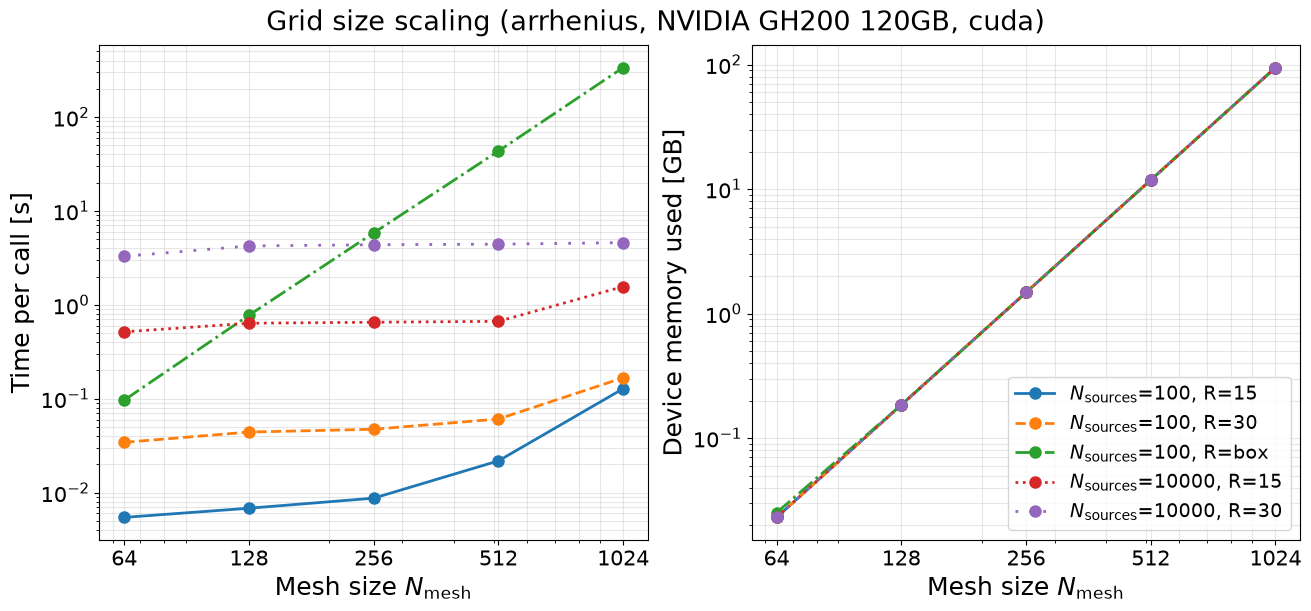

arrhenius, NVIDIA GH200 120GB, cuda, 100 sources
   R     N   time [s] calls t/source [ms] device [GB]  note
  15    64     0.0054     5         0.054        0.02  
  15   128     0.0068     5         0.068        0.18  
  15   256     0.0087     5         0.087        1.48  
  15   512     0.0218     5         0.218       11.81  
  15  1024     0.1278     5         1.278       94.49  
  30    64     0.0343     5         0.343        0.02  
  30   128     0.0441     5         0.441        0.18  
  30   256     0.0473     5         0.473        1.48  
  30   512     0.0607     5         0.607       11.81  
  30  1024     0.1669     5         1.669       94.49  
 box    64     0.0965     5         0.965        0.03  
 box   128     0.7746     5         7.746        0.18  
 box   256     5.8361     5        58.361        1.48  
 box   512    43.4237     3       434.237       11.81  
 box  1024   336.6325     1      3366.325       94.49  
arrhenius, NVIDIA GH200 120GB, cuda, 10000 sources


In [2]:
runs = load('B1_grid_size')
if runs:
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Grid size scaling', runs)
    curves = []
    for run in runs:
        for radius in ('15', '30', 'box'):
            rec = [r for r in ok(run['records']) if r['radius'] == radius]
            if rec:
                curves.append(((rec[0]['num_sources'], rkey(radius)), run, radius, rec))
    for i, (_, run, radius, rec) in enumerate(sorted(curves, key=lambda c: c[0])):
        N = np.array([r['mesh_size'] for r in rec])
        t = np.array([r['time_median_s'] for r in rec])
        mem = np.array([r['device_bytes_used'] or np.nan for r in rec]) / 1e9
        lab = leg(run, case_label(nsrc=rec[0]['num_sources'], R=radius))
        axs[0].loglog(N, t, marker='o', label=lab, **style(i))
        axs[1].loglog(N, mem, marker='o', label=lab, **style(i))
    axs[0].set_ylabel('Time per call [s]')
    axs[1].set_ylabel('Device memory used [GB]')
    for ax in axs:
        ax.set_xlabel('Mesh size $N_\\mathrm{mesh}$')
        ax.grid(True, which='both', alpha=0.3)
        ax.set_xticks([64, 128, 256, 512, 1024])
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    axs[-1].legend(loc=4)
    plt.show()

    for run in runs:
        print(f"{label(run)}, {run['params']['num_sources']} sources")
        print(f"{'R':>4} {'N':>5} {'time [s]':>10} {'calls':>5} {'t/source [ms]':>13} {'device [GB]':>11}  note")
        for r in run['records']:
            if 'skipped' in r:
                print(f"{r['radius']:>4} {r['mesh_size']:>5} {'':>10} {'':>5} {'':>13} {'':>11}  skipped: {r['skipped']}")
            else:
                used = (r['device_bytes_used'] or np.nan) / 1e9
                note = '' if r['valid'] else 'INVALID OUTPUT'
                print(f"{r['radius']:>4} {r['mesh_size']:>5} {r['time_median_s']:10.4f} {len(r['times_s']):>5} "
                      f"{1e3 * r['time_per_source_s']:13.3f} {used:11.2f}  {note}")

### B2. Source-count scaling
Fixed $N = 256$ (and $N = 100$ at $R = 15$), number of sources $1$–$10^6$, $R$ = 15 and 30: time, throughput (sources/s), memory.

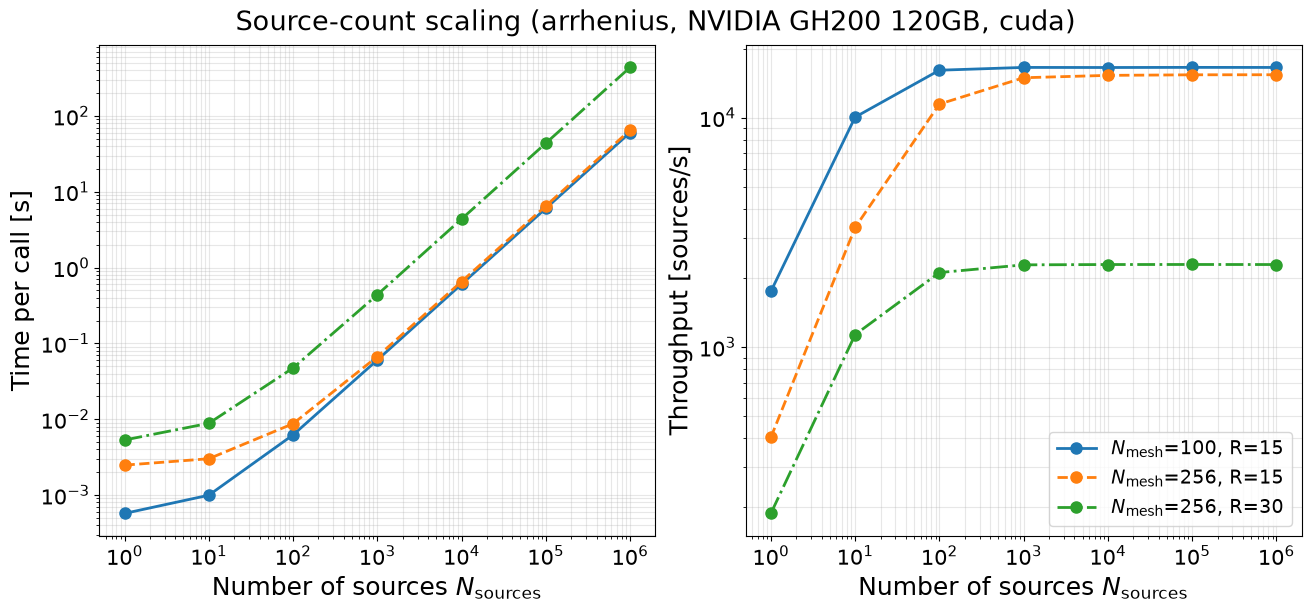

arrhenius, NVIDIA GH200 120GB, cuda, N=256, batch 8
   R  sources   time [s] calls   sources/s device [GB]  note
  15        1     0.0025     5       403.6        1.48  
  15       10     0.0030     5      3322.1        1.48  
  15      100     0.0087     5     11463.5        1.48  
  15     1000     0.0669     5     14936.6        1.48  
  15    10000     0.6537     5     15296.6        1.48  
  15   100000     6.5005     5     15383.5        1.48  
  15  1000000    64.9599     2     15394.1        1.50  
  30        1     0.0053     5       188.1        1.48  
  30       10     0.0088     5      1132.6        1.48  
  30      100     0.0473     5      2112.1        1.48  
  30     1000     0.4382     5      2282.0        1.48  
  30    10000     4.3682     5      2289.3        1.48  
  30   100000    43.6613     3      2290.4        1.48  
  30  1000000   436.8675     1      2289.0        1.50  
arrhenius, NVIDIA GH200 120GB, cuda, N=100, batch 8
   R  sources   time [s] calls   sour

In [3]:
runs = load('B2_num_sources')
if runs:
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Source-count scaling', runs)
    curves = []
    for run in runs:
        for radius in {r['radius'] for r in run['records']}:
            rec = [r for r in ok(run['records']) if r['radius'] == radius]
            if rec:
                curves.append(((run['params']['mesh_size'], rkey(radius)), run, radius, rec))
    for i, ((N, _), run, radius, rec) in enumerate(sorted(curves, key=lambda c: c[0])):
        n = np.array([r['num_sources'] for r in rec])
        lab = leg(run, case_label(N=N, R=radius))
        axs[0].loglog(n, [r['time_median_s'] for r in rec], marker='o', label=lab, **style(i))
        axs[1].loglog(n, [r['sources_per_s'] for r in rec], marker='o', label=lab, **style(i))
    axs[0].set_ylabel('Time per call [s]')
    axs[1].set_ylabel('Throughput [sources/s]')
    for ax in axs:
        ax.set_xlabel('Number of sources $N_\\mathrm{sources}$')
        ax.grid(True, which='both', alpha=0.3)
    axs[-1].legend(loc=4)
    plt.show()

    for run in runs:
        print(f"{label(run)}, N={run['params']['mesh_size']}, batch {run['params']['batch_size']}")
        print(f"{'R':>4} {'sources':>8} {'time [s]':>10} {'calls':>5} {'sources/s':>11} {'device [GB]':>11}  note")
        for r in run['records']:
            if 'skipped' in r:
                print(f"{r['radius']:>4} {r['num_sources']:>8}  skipped: {r['skipped']}")
                continue
            used = (r['device_bytes_used'] or np.nan) / 1e9
            print(f"{r['radius']:>4} {r['num_sources']:>8} {r['time_median_s']:10.4f} {len(r['times_s']):>5} "
                  f"{r['sources_per_s']:11.1f} {used:11.2f}  {'' if r['valid'] else 'INVALID OUTPUT'}")

### B3. Raytracing radius scaling
Fixed $N$ (256, and 100 as a non-power-of-2 grid) and number of sources, $R$ swept: cost per call, and device memory measured after each radius compared with the estimate in the docs ([tutorials/memory](https://pyc2ray.readthedocs.io/en/latest/tutorials/memory.html)). The table also lists the fraction of the $R$ = box photoionization rate captured at each $R$ (specific to this nearly transparent test medium).

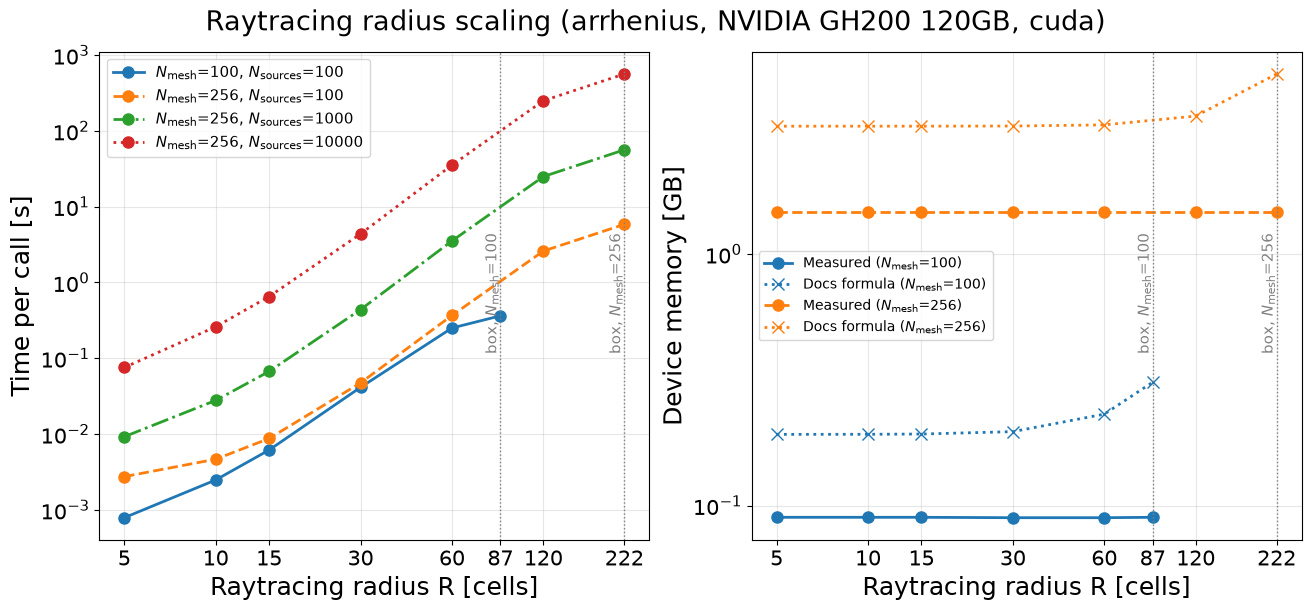

arrhenius, NVIDIA GH200 120GB, cuda, N=256, batch 8
sources     R R [cells]   time [s] calls rate frac.  cells<1% med. deficit mem [GB] docs [GB]  note
    100     5       5.0     0.0027     5     0.0399    0.0000       1.0000     1.47      3.22  
    100    10      10.0     0.0047     5     0.0817    0.0000       1.0000     1.47      3.22  
    100    15      15.0     0.0088     5     0.1226    0.0000       1.0000     1.47      3.22  
    100    30      30.0     0.0474     5     0.2401    0.0001       1.0000     1.47      3.23  
    100    60      60.0     0.3678     5     0.4557    0.0001       0.6432     1.47      3.26  
    100   120     120.0     2.5978     5     0.8199    0.0005       0.2126     1.47      3.53  
    100   box     221.7     5.8481     5     1.0000    1.0000       0.0000     1.47      5.19  
   1000     5       5.0     0.0092     5     0.0399    0.0000       1.0000     1.48      3.22  
   1000    10      10.0     0.0278     5     0.0817    0.0000       1.0000     1

In [4]:
runs = load('B3_radius')
if runs:
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Raytracing radius scaling', runs)
    curves = []
    for run in runs:
        for nsrc in {r['num_sources'] for r in ok(run['records'])}:
            rec = [r for r in ok(run['records']) if r['num_sources'] == nsrc]
            curves.append(((run['params']['mesh_size'], nsrc), run, rec))
    mem_shown = set()  # memory is independent of the number of sources: one curve per (system, N_mesh)
    for i, ((N, nsrc), run, rec) in enumerate(sorted(curves, key=lambda c: c[0])):
        R = np.array([r['R_max'] for r in rec])
        mem = [(r.get('device_bytes_used_after_calls') or r['device_bytes_used'] or np.nan) / 1e9 for r in rec]
        axs[0].loglog(R, [r['time_median_s'] for r in rec], marker='o', label=leg(run, case_label(N=N, nsrc=nsrc)), **style(i))
        if (label(run), N) not in mem_shown:
            mem_shown.add((label(run), N))
            mlab = leg(run, case_label(N=N))
            axs[1].loglog(R, mem, marker='o', label=f'Measured ({mlab})', **style(i))
            if 'device_bytes_docs_formula' in rec[0]:
                axs[1].loglog(R, [r['device_bytes_docs_formula'] / 1e9 for r in rec], marker='x', color=f'C{i % 10}',
                              ls=':', label=f'Docs formula ({mlab})')
    # tick at every radius (by value); the whole-box radius differs per N, so mark it with a line
    ticks = sorted({r['R_max'] for run in runs for r in ok(run['records'])})
    boxes = sorted({(r['R_max'], r['mesh_size']) for run in runs for r in ok(run['records']) if r['radius'] == 'box'})
    axs[0].set_ylabel('Time per call [s]')
    axs[1].set_ylabel('Device memory [GB]')
    for ax in axs:
        ax.set_xlabel('Raytracing radius R [cells]')
        ax.grid(True, which='both', alpha=0.3)
        ax.set_xticks(ticks, [f'{t:.0f}' for t in ticks])
        ax.minorticks_off()
        for R_box, N in boxes:
            ax.axvline(R_box, color='gray', ls=':', lw=1)
            ax.text(R_box, 0.5, f' box, $N_\\mathrm{{mesh}}$={N}', transform=ax.get_xaxis_transform(), rotation=90,
                    ha='right', va='center', fontsize=11, color='gray')
    axs[0].legend(loc=2, fontsize=11)
    axs[1].legend(loc=0, fontsize=10)
    plt.show()

    for run in runs:
        print(f"{label(run)}, N={run['params']['mesh_size']}, batch {run['params']['batch_size']}")
        print(f"{'sources':>7} {'R':>5} {'R [cells]':>9} {'time [s]':>10} {'calls':>5} {'rate frac.':>10} {'cells<1%':>9} "
              f"{'med. deficit':>12} {'mem [GB]':>8} {'docs [GB]':>9}  note")
        for r in run['records']:
            if 'skipped' in r:
                print(f"{'':>7} {r['radius']:>5} {r['R_max']:9.1f}  skipped: {r['skipped']}")
                continue
            mem = (r.get('device_bytes_used_after_calls') or r['device_bytes_used'] or np.nan) / 1e9
            docs = r.get('device_bytes_docs_formula', np.nan) / 1e9
            print(f"{r['num_sources']:>7} {r['radius']:>5} {r['R_max']:9.1f} {r['time_median_s']:10.4f} {len(r['times_s']):>5} "
                  f"{r['rate_fraction']:10.4f} {r['cells_within_1pc']:9.4f} {r['median_rel_deficit']:12.4f} "
                  f"{mem:8.2f} {docs:9.2f}  {'' if r['valid'] else 'INVALID OUTPUT'}")

### B4. `source_batch_size` sweep
Large number of sources, batch size swept: throughput/memory sweet spot on H100 (GH200).

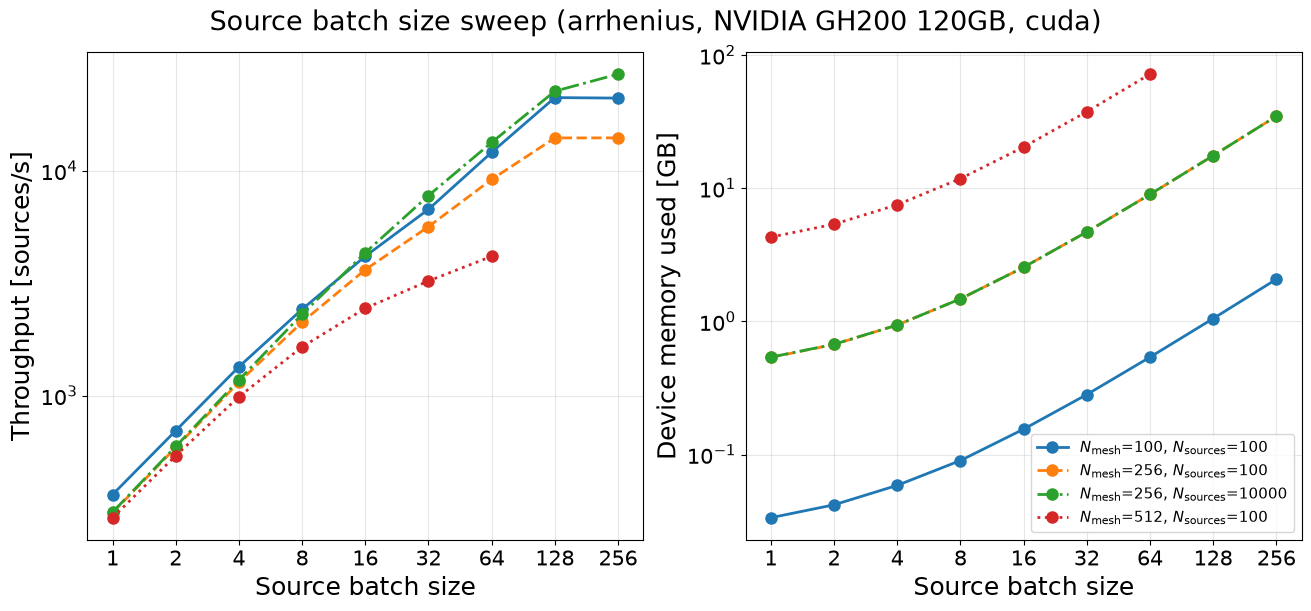

arrhenius, NVIDIA GH200 120GB, cuda, N=256, R=30
sources batch   time [s] calls   sources/s device [GB]  note
    100     1     0.3320     5       301.2        0.54  
    100     2     0.1702     5       587.7        0.67  
    100     4     0.0871     5      1147.5        0.94  
    100     8     0.0471     5      2122.4        1.48  
    100    16     0.0275     5      3631.3        2.55  
    100    32     0.0177     5      5641.9        4.70  
    100    64     0.0109     5      9151.6        8.99  
    100   128     0.0071     5     14001.4       17.58  
    100   256     0.0071     5     14004.4       34.76  
  10000     1    32.9920     4       303.1        0.54  
  10000     2    16.8453     5       593.6        0.67  
  10000     4     8.5207     5      1173.6        0.94  
  10000     8     4.3483     5      2299.7        1.48  
  10000    16     2.3137     5      4322.0        2.55  
  10000    32     1.2891     5      7757.4        4.70  
  10000    64     0.7480     5     

In [5]:
runs = load('B4_batch_size')
if runs:
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Source batch size sweep', runs)
    curves = []
    for run in runs:
        for nsrc in {r['num_sources'] for r in run['records']}:
            rec = [r for r in ok(run['records']) if r['num_sources'] == nsrc]
            if rec:
                curves.append(((run['params']['mesh_size'], nsrc), run, rec))
    for i, ((N, nsrc), run, rec) in enumerate(sorted(curves, key=lambda c: c[0])):
        b = np.array([r['batch_size'] for r in rec])
        lab = leg(run, case_label(N=N, nsrc=nsrc))
        axs[0].loglog(b, [r['sources_per_s'] for r in rec], marker='o', label=lab, **style(i))
        axs[1].loglog(b, [(r['device_bytes_used'] or np.nan) / 1e9 for r in rec], marker='o', label=lab, **style(i))
    batches = sorted({r['batch_size'] for run in runs for r in run['records']})
    axs[0].set_ylabel('Throughput [sources/s]')
    axs[1].set_ylabel('Device memory used [GB]')
    for ax in axs:
        ax.set_xlabel('Source batch size')
        ax.grid(True, which='both', alpha=0.3)
        ax.set_xticks(batches)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.minorticks_off()
    axs[-1].legend(loc=4, fontsize=11)
    plt.show()

    for run in runs:
        print(f"{label(run)}, N={run['params']['mesh_size']}, R={run['params']['radius']}")
        print(f"{'sources':>7} {'batch':>5} {'time [s]':>10} {'calls':>5} {'sources/s':>11} {'device [GB]':>11}  note")
        for r in run['records']:
            if 'skipped' in r:
                print(f"{r['num_sources']:>7} {r['batch_size']:>5}  skipped: {r['skipped']}")
                continue
            used = (r['device_bytes_used'] or np.nan) / 1e9
            print(f"{r['num_sources']:>7} {r['batch_size']:>5} {r['time_median_s']:10.4f} {len(r['times_s']):>5} {r['sources_per_s']:11.1f} "
                  f"{used:11.2f}  {'' if r['valid'] else 'INVALID OUTPUT'}")

### B5. Host↔device transfer overhead
Time spent copying density / column density / ionization arrays per call vs. kernel time, for $R$ = 15 and 30 cells. The transfers themselves do not depend on $R$ or the number of sources; the call time, and so the transfer fraction, does.

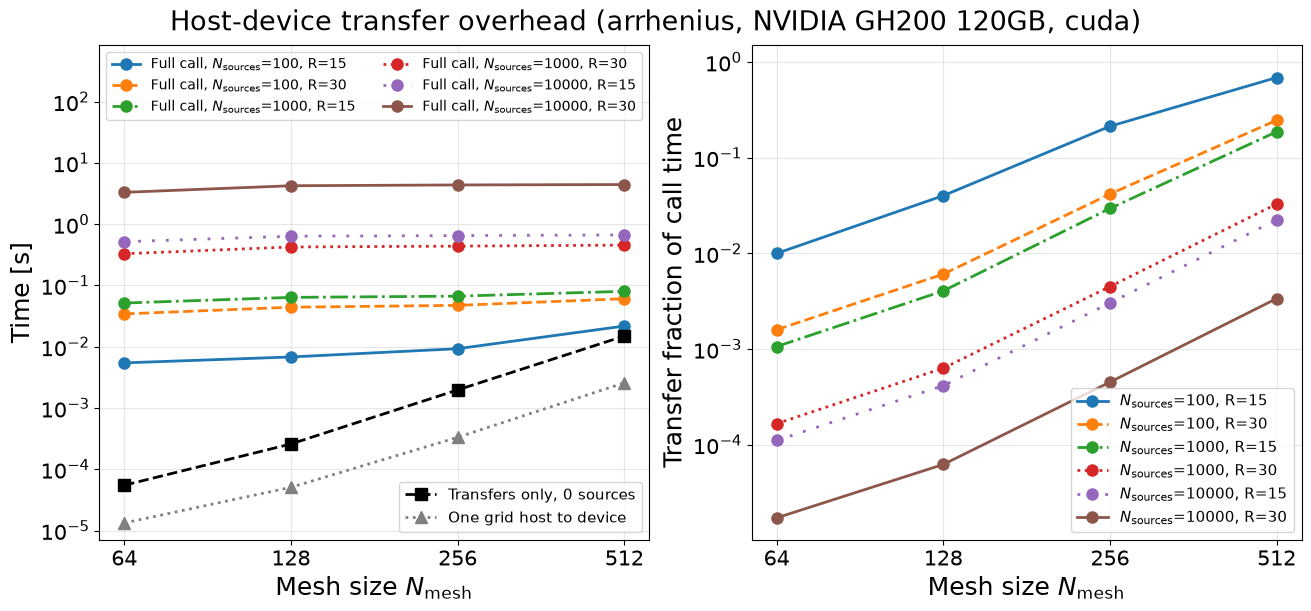

arrhenius, NVIDIA GH200 120GB, cuda
   R sources     N  H2D [ms] H2D [GB/s] transfers [ms]  [GB/s]  call [ms] fraction
  15     100    64      0.01      164.3           0.05   115.5       5.45     0.01
  15     100   128      0.05      343.0           0.27   184.4       6.81     0.04
  15     100   256      0.33      404.4           1.98   203.6       9.29     0.21
  15     100   512      2.58      416.2          14.96   215.3      21.78     0.69
  15    1000    64      0.01      157.5           0.05   114.4      51.68     0.00
  15    1000   128      0.05      330.3           0.26   194.2      63.90     0.00
  15    1000   256      0.33      403.6           1.97   203.9      66.95     0.03
  15    1000   512      2.58      416.0          14.96   215.3      80.22     0.19
  15   10000    64      0.01      157.7           0.06   109.4     517.59     0.00
  15   10000   128      0.05      318.6           0.26   190.9     636.03     0.00
  15   10000   256      0.34      399.0           1

In [6]:
runs = load('B5_transfer')
if runs:
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Host-device transfer overhead', runs)
    curves = []
    for run in runs:
        for nsrc, radius in {(r['num_sources'], r['radius']) for r in ok(run['records'])}:
            rec = [r for r in ok(run['records']) if r['num_sources'] == nsrc and r['radius'] == radius]
            curves.append(((nsrc, rkey(radius)), run, radius, rec))
    for i, ((nsrc, _), run, radius, rec) in enumerate(sorted(curves, key=lambda c: c[0])):
        N = np.array([r['mesh_size'] for r in rec])
        lab = leg(run, case_label(nsrc=nsrc, R=radius))
        axs[0].loglog(N, [r['time_median_s'] for r in rec], marker='o', label=f'Full call, {lab}', **style(i))
        axs[1].loglog(N, [r['transfer_fraction'] for r in rec], marker='o', label=lab, **style(i))
    # transfers do not depend on R or the number of sources: show them once per system/build
    shown = set()
    for _, run, radius, rec in curves:
        if label(run) in shown:
            continue
        shown.add(label(run))
        N = np.array([r['mesh_size'] for r in rec])
        axs[0].loglog(N, [r['t_overhead_median_s'] for r in rec], '--', marker='s', color='k', label=leg(run, 'Transfers only, 0 sources'))
        axs[0].loglog(N, [r['t_h2d_median_s'] for r in rec], ':', marker='^', color='gray', label=leg(run, 'One grid host to device'))
    axs[0].set_ylabel('Time [s]')
    axs[1].set_ylabel('Transfer fraction of call time')
    axs[1].set_ylim(top=1.5)
    for ax in axs:
        ax.set_xlabel('Mesh size $N_\\mathrm{mesh}$')
        ax.grid(True, which='both', alpha=0.3)
        ax.set_xticks(sorted({r['mesh_size'] for run in runs for r in run['records']}))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.minorticks_off()
    lines = axs[0].get_lines()
    ref = [l for l in lines if l.get_label().startswith(('Transfers only', 'One grid'))]
    calls = [l for l in lines if l not in ref]
    axs[0].add_artist(axs[0].legend(handles=calls, loc=2, fontsize=10, ncol=2))
    axs[0].legend(handles=ref, loc=4, fontsize=11)
    axs[0].set_ylim(top=axs[0].get_ylim()[1] * 1e2)
    axs[1].legend(loc=4, fontsize=11)
    plt.show()

    for run in runs:
        print(label(run))
        print(f"{'R':>4} {'sources':>7} {'N':>5} {'H2D [ms]':>9} {'H2D [GB/s]':>10} {'transfers [ms]':>14} {'[GB/s]':>7} {'call [ms]':>10} {'fraction':>8}")
        for r in run['records']:
            print(f"{r['radius']:>4} {r['num_sources']:>7} {r['mesh_size']:>5} {1e3 * r['t_h2d_median_s']:9.2f} {r['h2d_GBps']:10.1f} {1e3 * r['t_overhead_median_s']:14.2f} "
                  f"{r['overhead_GBps']:7.1f} {1e3 * r['time_median_s']:10.2f} {r['transfer_fraction']:8.2f}")

## C. Multi-GPU / multi-node scaling
pyC2Ray's MPI mode: every rank (one GPU each) holds the whole grid and raytraces its share of the sources; the photoionization rates are summed with MPI Reduce + Bcast on the host. The step time includes both.
### C1. Strong scaling
Fixed total problem, $P$ = 1/2/4 GPUs on one node and 8 GPUs on two nodes.

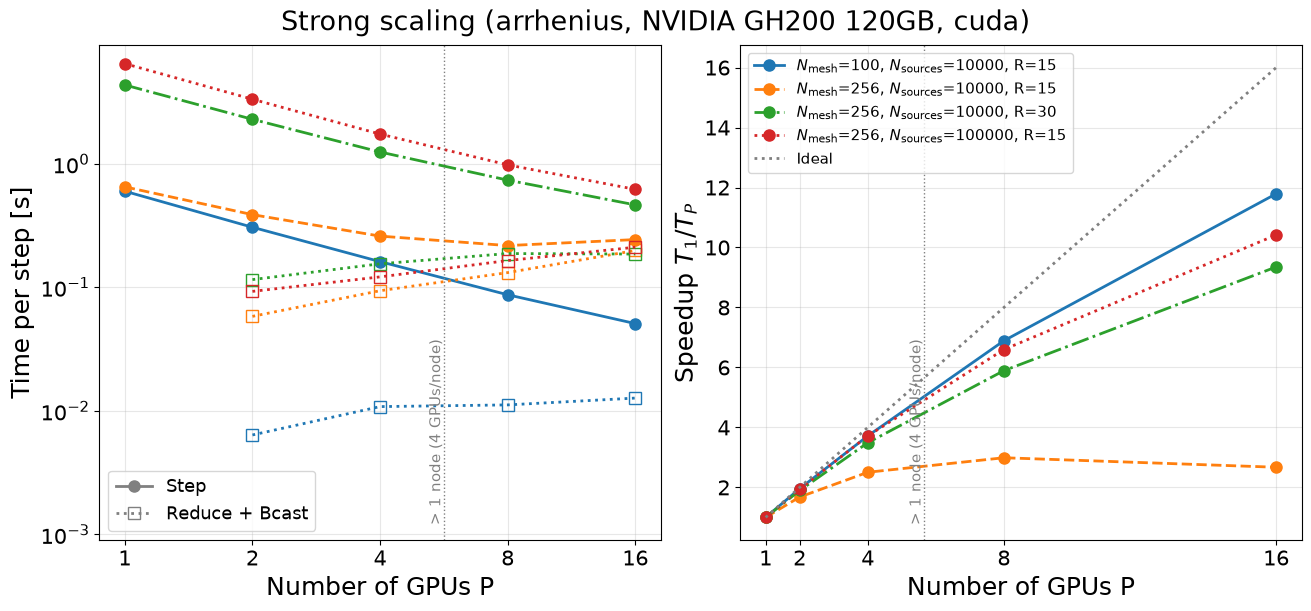

arrhenius, NVIDIA GH200 120GB, cuda: N_mesh=100, N_sources=10000, R=15
  P  step [s] raytracing [s]  comm [s] imbalance speedup efficiency
  1    0.6004         0.6003    0.0000     1.000    1.00       1.00
  2    0.3067         0.3013    0.0064     1.002    1.96       0.98
  4    0.1616         0.1529    0.0108     1.010    3.72       0.93
  8    0.0871         0.0774    0.0112     1.017    6.89       0.86
 16    0.0509         0.0400    0.0127     1.036   11.79       0.74
arrhenius, NVIDIA GH200 120GB, cuda: N_mesh=256, N_sources=10000, R=15
  P  step [s] raytracing [s]  comm [s] imbalance speedup efficiency
  1    0.6514         0.6514    0.0000     1.000    1.00       1.00
  2    0.3879         0.3303    0.0583     1.001    1.68       0.84
  4    0.2600         0.1700    0.0940     1.012    2.50       0.63
  8    0.2179         0.0905    0.1317     1.034    2.99       0.37
 16    0.2438         0.0495    0.1989     1.095    2.67       0.17
arrhenius, NVIDIA GH200 120GB, cuda: N_mes

In [7]:
runs = load('C1_strong_scaling')
if runs:
    # one results file per number of GPUs: group the records by system and case
    cases = {}
    for run in runs:
        for r in ok(run['records']):
            cases.setdefault((label(run), r['mesh_size'], r['radius'], r['num_sources']), []).append(r)
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Strong scaling', runs)
    P_all = sorted({r['nprocs'] for recs in cases.values() for r in recs})
    order = sorted(cases, key=lambda k: (k[0], k[1], k[3], rkey(k[2])))  # system, N_mesh, N_sources, R
    for i, (lab, N, radius, nsrc) in enumerate(order):
        recs = cases[(lab, N, radius, nsrc)]
        recs = sorted(recs, key=lambda r: r['nprocs'])
        P = np.array([r['nprocs'] for r in recs])
        step = np.array([r['time_median_s'] for r in recs])
        run = next(run for run in runs if label(run) == lab)
        case = leg(run, case_label(N=N, nsrc=nsrc, R=radius))
        axs[0].loglog(P, step, marker='o', label=f'Step ({case})', **style(i))
        multi = P > 1  # nothing to communicate with one GPU
        axs[0].loglog(P[multi], np.array([r['t_comm_median_s'] for r in recs])[multi], marker='s', mfc='none',
                      color=f'C{i % 10}', ls=':', label=f'Reduce + Bcast ({case})')
        if P[0] == 1:
            axs[1].plot(P, step[0] / step, marker='o', label=case, **style(i))
    axs[1].plot(P_all, P_all, color='gray', ls=':', label='Ideal')
    mark_nodes(axs, runs, P_all)
    axs[0].set_ylabel('Time per step [s]')
    axs[1].set_ylabel('Speedup $T_1 / T_P$')
    for ax in axs:
        ax.set_xlabel('Number of GPUs P')
        ax.grid(True, which='both', alpha=0.3)
        ax.set_xticks(P_all, [str(x) for x in P_all])
        ax.minorticks_off()
    line_types(axs[0])
    axs[1].legend(loc=2, fontsize=11)
    plt.show()

    for lab, N, radius, nsrc in order:
        recs = cases[(lab, N, radius, nsrc)]
        print(f'{lab}: N_mesh={N}, N_sources={nsrc}, R={radius}')
        print(f"{'P':>3} {'step [s]':>9} {'raytracing [s]':>14} {'comm [s]':>9} {'imbalance':>9} {'speedup':>7} {'efficiency':>10}")
        recs = sorted(recs, key=lambda r: r['nprocs'])
        t1 = recs[0]['time_median_s'] if recs[0]['nprocs'] == 1 else np.nan
        for r in recs:
            s = t1 / r['time_median_s']
            print(f"{r['nprocs']:>3} {r['time_median_s']:9.4f} {r['t_rt_max_median_s']:14.4f} {r['t_comm_median_s']:9.4f} "
                  f"{r['imbalance']:9.3f} {s:7.2f} {s / r['nprocs']:10.2f}")

### C2. Weak scaling
Problem size grows with the number of GPUs.

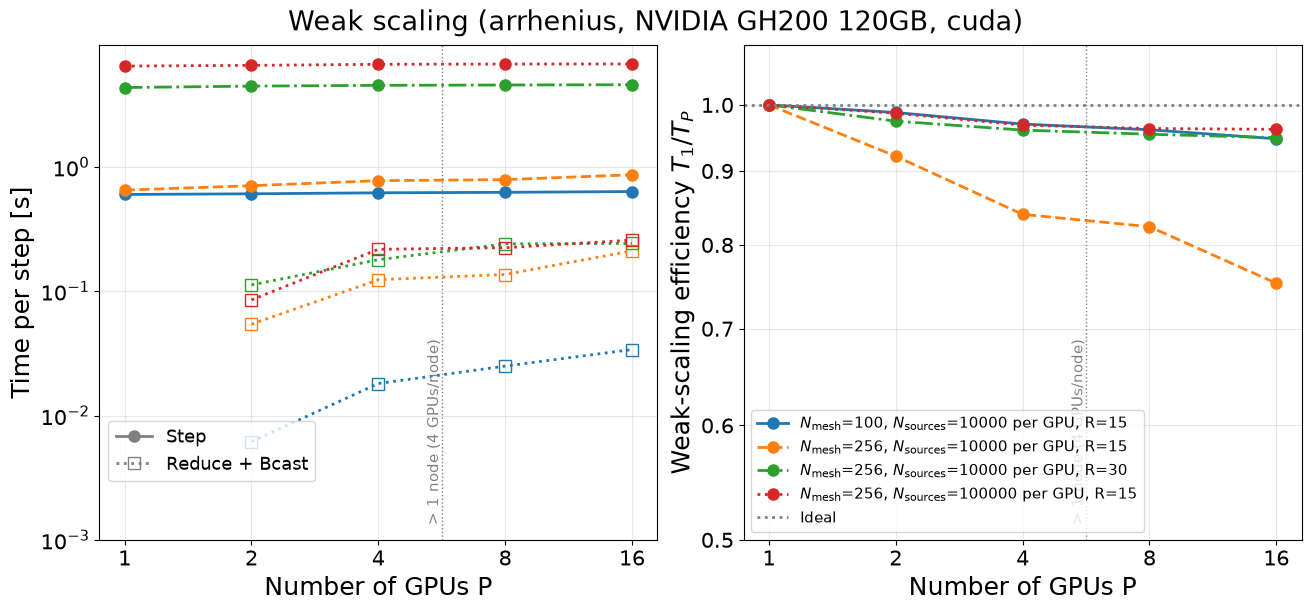

arrhenius, NVIDIA GH200 120GB, cuda: N_mesh=100, N_sources=10000 per GPU, R=15
  P  sources  step [s] raytracing [s]  comm [s] imbalance efficiency
  1    10000    0.6003         0.6003    0.0000     1.000       1.00
  2    20000    0.6077         0.6020    0.0062     1.001       0.99
  4    40000    0.6190         0.6110    0.0181     1.011       0.97
  8    80000    0.6246         0.6145    0.0250     1.018       0.96
 16   160000    0.6337         0.6220    0.0340     1.028       0.95
arrhenius, NVIDIA GH200 120GB, cuda: N_mesh=256, N_sources=10000 per GPU, R=15
  P  sources  step [s] raytracing [s]  comm [s] imbalance efficiency
  1    10000    0.6508         0.6508    0.0000     1.000       1.00
  2    20000    0.7063         0.6533    0.0543     1.001       0.92
  4    40000    0.7748         0.6639    0.1238     1.012       0.84
  8    80000    0.7902         0.6599    0.1362     1.007       0.82
 16   160000    0.8647         0.6595    0.2111     1.009       0.75
arrhenius, NVI

In [8]:
runs = load('C2_weak_scaling')
if runs:
    cases = {}
    for run in runs:
        for r in ok(run['records']):
            cases.setdefault((label(run), r['mesh_size'], r['radius'], r['sources_per_rank']), []).append(r)
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    leg = title(fig, 'Weak scaling', runs)
    P_all = sorted({r['nprocs'] for recs in cases.values() for r in recs})
    order = sorted(cases, key=lambda k: (k[0], k[1], k[3], rkey(k[2])))  # system, N_mesh, N_sources per GPU, R
    for i, (lab, N, radius, per) in enumerate(order):
        recs = cases[(lab, N, radius, per)]
        recs = sorted(recs, key=lambda r: r['nprocs'])
        P = np.array([r['nprocs'] for r in recs])
        step = np.array([r['time_median_s'] for r in recs])
        run = next(run for run in runs if label(run) == lab)
        case = leg(run, case_label(N=N, nsrc=per, R=radius, per_gpu=True))
        axs[0].loglog(P, step, marker='o', label=f'Step ({case})', **style(i))
        multi = P > 1  # nothing to communicate with one GPU
        axs[0].loglog(P[multi], np.array([r['t_comm_median_s'] for r in recs])[multi], marker='s', mfc='none',
                      color=f'C{i % 10}', ls=':', label=f'Reduce + Bcast ({case})')
        if P[0] == 1:
            axs[1].loglog(P, step[0] / step, marker='o', label=case, **style(i))
    axs[1].axhline(1, color='gray', ls=':', label='Ideal')
    mark_nodes(axs, runs, P_all)
    axs[0].set_ylabel('Time per step [s]')
    axs[1].set_ylabel('Weak-scaling efficiency $T_1 / T_P$')
    axs[1].set_ylim(0.5, 1.1)
    axs[1].set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0], ['0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])
    axs[1].minorticks_off()
    for ax in axs:
        ax.set_xlabel('Number of GPUs P')
        ax.grid(True, which='both', alpha=0.3)
        ax.set_xticks(P_all, [str(x) for x in P_all])
        ax.minorticks_off()
    line_types(axs[0], bbox_to_anchor=(0, 0.1))
    axs[0].set_ylim(bottom=1e-3)
    axs[1].legend(loc=3, fontsize=11)
    plt.show()

    for lab, N, radius, per in order:
        recs = cases[(lab, N, radius, per)]
        print(f'{lab}: N_mesh={N}, N_sources={per} per GPU, R={radius}')
        print(f"{'P':>3} {'sources':>8} {'step [s]':>9} {'raytracing [s]':>14} {'comm [s]':>9} {'imbalance':>9} {'efficiency':>10}")
        recs = sorted(recs, key=lambda r: r['nprocs'])
        t1 = recs[0]['time_median_s'] if recs[0]['nprocs'] == 1 else np.nan
        for r in recs:
            print(f"{r['nprocs']:>3} {r['num_sources']:>8} {r['time_median_s']:9.4f} {r['t_rt_max_median_s']:14.4f} "
                  f"{r['t_comm_median_s']:9.4f} {r['imbalance']:9.3f} {t1 / r['time_median_s']:10.2f}")

## D. End-to-end timestep
Full `evolve3D` step: GPU raytracing vs. CPU (Fortran) chemistry time split.

In [9]:
runs = load('D_timestep')

D_timestep: no results yet. Run benchmark_scripts/D_timestep.py (e.g. sbatch benchmark_scripts/jobs/arrhenius_D.sh)


## E. Roofline characterization
Achieved vs. theoretical peak HBM bandwidth for the raytracing kernel.

In [10]:
runs = load('E_roofline')

E_roofline: not implemented yet (benchmark_scripts/E_roofline.py does not exist).
